Generating synthetic retail dataset...
  CustomerID  Recency_Days  Frequency_Purchases  Avg_Spend_USD  Tenure_Days  \
0  CUST_0001            21                   13      83.027988          421   
1  CUST_0002           135                   11      72.988853          240   
2  CUST_0003            59                    7      51.930626          396   
3  CUST_0004            41                    5      77.569932          699   
4  CUST_0005             7                    7      91.212122          599   

   Churned    Total_CLV  
0        0  1079.363844  
1        1   802.877378  
2        0   363.514384  
3        0   387.849662  
4        0   638.484853  

--- Dataset Insights ---
Total Customers: 1000
Churn Rate: 24.90%

Average Metrics by Customer Status:
         Recency_Days  Frequency_Purchases  Avg_Spend_USD   Total_CLV
Churned                                                              
0           23.202397             8.017310      65.275612  522.902956
1          103.8

C:\Users\Pratham\AppData\Local\Temp\ipykernel_24392\3436809102.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y='Recency_Days', data=df, palette='Set2')
C:\Users\Pratham\AppData\Local\Temp\ipykernel_24392\3436809102.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


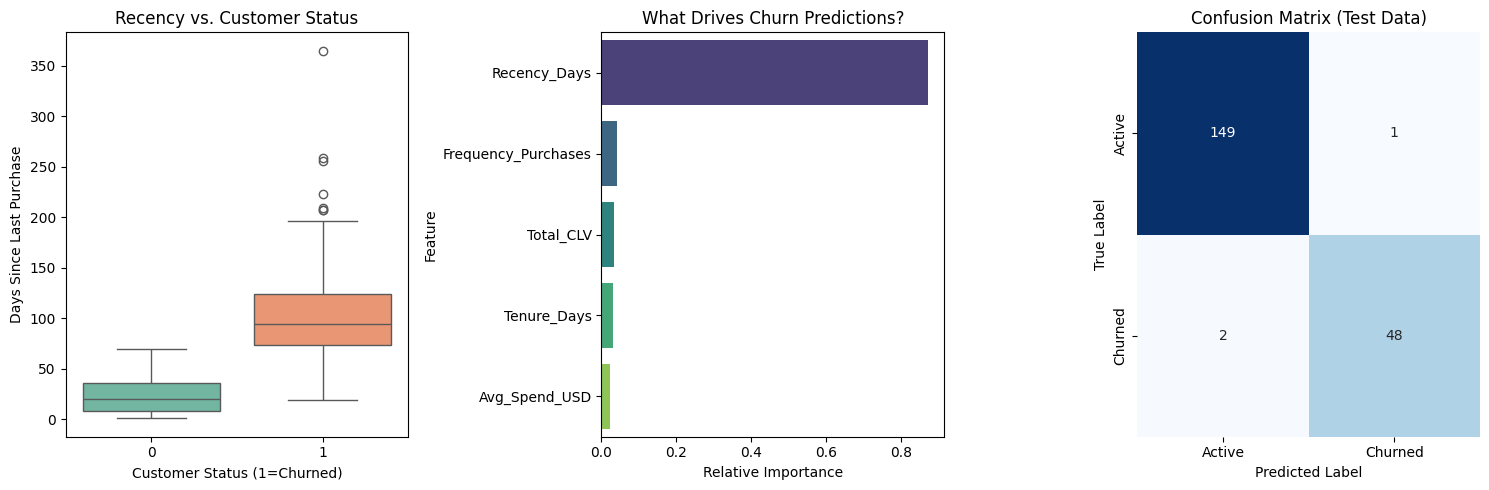

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


np.random.seed(42)


# STEP 1: GENERATE REAL-WORLD RETAIL DATA

def generate_retail_data(num_customers=1000):
    print("Generating synthetic retail dataset...")
    
    # Generate Customer IDs
    customer_ids = [f"CUST_{i:04d}" for i in range(1, num_customers + 1)]
    
    # Feature 1: Recency (Days since last purchase - highly predictive of churn)
    recency = np.random.exponential(scale=45, size=num_customers).astype(int)
    recency = np.clip(recency, 1, 365) # keep within a year
    
    # Feature 2: Frequency (Total number of purchases in the last year)
    frequency = np.random.poisson(lam=8, size=num_customers)
    frequency = np.clip(frequency, 1, 50)
    
    # Feature 3: Monetary Value (Average spend per order)
    avg_spend = np.random.normal(loc=65, scale=25, size=num_customers)
    avg_spend = np.clip(avg_spend, 10, 300)
    
    # Feature 4: Tenure (How long they've been a customer in days)
    tenure = np.random.randint(30, 730, size=num_customers)
    # Ensure tenure is greater than recency
    tenure = np.where(tenure <= recency, recency + np.random.randint(10, 100), tenure)
    
    # Define Ground Truth: Churn (1 = Churned, 0 = Active)
    # In retail, high recency + low frequency usually implies a customer has left.
    # Let's create a probability score to dictate the label realistically
    churn_prob = (recency / 365.0) * 0.6 + (1 / (frequency + 1)) * 0.3
    churn_prob = np.clip(churn_prob, 0, 1)
    churn = (churn_prob > np.percentile(churn_prob, 75)).astype(int) # Top 25% risk churns
    
    # Compile DataFrame
    df = pd.DataFrame({
        'CustomerID': customer_ids,
        'Recency_Days': recency,
        'Frequency_Purchases': frequency,
        'Avg_Spend_USD': avg_spend,
        'Tenure_Days': tenure,
        'Churned': churn
    })
    
    # Feature Engineering: Total Lifetime Value (CLV) approximation
    df['Total_CLV'] = df['Frequency_Purchases'] * df['Avg_Spend_USD']
    
    return df

df = generate_retail_data()
print(df.head())


print("\n--- Dataset Insights ---")
print(f"Total Customers: {df.shape[0]}")
print(f"Churn Rate: {df['Churned'].mean() * 100:.2f}%")
print("\nAverage Metrics by Customer Status:")
print(df.groupby('Churned')[['Recency_Days', 'Frequency_Purchases', 'Avg_Spend_USD', 'Total_CLV']].mean())


X = df[['Recency_Days', 'Frequency_Purchases', 'Avg_Spend_USD', 'Tenure_Days', 'Total_CLV']]
y = df['Churned']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and Train Random Forest
model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n--- Model Performance Evaluation ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importances
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending=False)
print("\nFeature Importances (What drives Churn?):")
print(feature_imp_df)


plt.figure(figsize=(15, 5))

# Plot 1: Recency vs Churn
plt.subplot(1, 3, 1)
sns.boxplot(x='Churned', y='Recency_Days', data=df, palette='Set2')
plt.title('Recency vs. Customer Status')
plt.xlabel('Customer Status (1=Churned)')
plt.ylabel('Days Since Last Purchase')

# Plot 2: Feature Importance
plt.subplot(1, 3, 2)
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('What Drives Churn Predictions?')
plt.xlabel('Relative Importance')

# Plot 3: Confusion Matrix
plt.subplot(1, 3, 3)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'])
plt.title('Confusion Matrix (Test Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()